# Seasonal Agriculture Performance Analysis

This notebook analyzes the VOIS AICTE major-project dataset as a focused seasonal decision problem.

The analysis answers four practical questions:
1. How does farm performance change across Kharif, Rabi and Zaid?
2. Which crop-season combinations create the strongest economic outcomes?
3. How does irrigation and water productivity affect performance?
4. What evidence can be turned into practical seasonal recommendations?

The workflow includes data validation, missing-value handling, descriptive analysis, group comparisons, non-parametric significance testing, relationship analysis, outlier checks, visualizations and a transparent Seasonal Opportunity Score.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_PATH = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


## 1. Dataset validation

The supplied data contains 4,000 farm records and 28 variables covering location, crop, season, environmental conditions, inputs, yield, economics, water use and disease/pest risk.


In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nSeasons:")
display(df["Season"].value_counts().rename("farms").to_frame())

print("\nUnique crops:", df["Crop"].nunique())
print("Unique states:", df["State"].nunique())
print("Unique districts:", df["District"].nunique())
print("Unique irrigation methods:", df["Irrigation_Method"].nunique())

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].rename("missing_values").to_frame())


Rows: 4000
Columns: 28

Seasons:


,farms
Season,
Kharif,1779
Rabi,1627
Zaid,594



Unique crops: 8
Unique states: 8
Unique districts: 10
Unique irrigation methods: 4


,missing_values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


## 2. Data cleaning and derived metrics

Only three numeric fields contain missing values: rainfall, soil moisture and yield. Numeric gaps are imputed with the median so that the full set of farm records can be retained without creating artificial extremes.

Two decision metrics are added:
- **Profit Margin %** = profit / revenue × 100
- **Return on Cost %** = profit / total cost × 100


In [3]:
df_clean = df.copy()

numeric_fill = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
for col in numeric_fill:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean["Profit_Margin_pct"] = np.where(
    df_clean["Revenue_INR"] != 0,
    df_clean["Profit_INR"] / df_clean["Revenue_INR"] * 100,
    np.nan
)

df_clean["Return_on_Cost_pct"] = np.where(
    df_clean["Total_Cost_INR"] != 0,
    df_clean["Profit_INR"] / df_clean["Total_Cost_INR"] * 100,
    np.nan
)

print("Remaining missing values:", int(df_clean.isna().sum().sum()))
display(df_clean[["Yield_Tonnes_Ha","Revenue_INR","Total_Cost_INR","Profit_INR",
                  "Water_Used_m3","Water_Efficiency_t_per_1000m3",
                  "Profit_Margin_pct","Return_on_Cost_pct"]].describe().T)


Remaining missing values: 0


,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,"4,000.000",5.242,13.312,0.300,1.050,1.740,2.830,101.440
Revenue_INR,"4,000.000","637,860.048","636,974.710","6,107.000","207,517.250","456,830.500","836,874.750","5,080,900.000"
Total_Cost_INR,"4,000.000","526,303.583","294,419.141","26,826.000","274,577.500","519,082.500","761,996.500","1,349,990.000"
Profit_INR,"4,000.000","111,556.465","545,081.891","-1,019,223.000","-148,731.750","3,673.000","216,187.750","4,345,421.000"
Water_Used_m3,"4,000.000","6,045.570","5,572.944",128.000,"2,268.750","4,435.000","7,829.750","40,902.000"
Water_Efficiency_t_per_1000m3,"4,000.000",5.385,8.838,0.135,1.661,2.938,5.150,79.800
Profit_Margin_pct,"4,000.000",-45.492,158.085,"-1,461.851",-60.193,1.146,32.886,85.921
Return_on_Cost_pct,"4,000.000",22.558,91.726,-93.597,-37.575,1.160,49.000,610.289


## 3. Seasonal performance

This is the core comparison required by the problem statement. We compare yield, profitability, water efficiency, risk and economic margin by season.


In [4]:
season_summary = (
    df_clean.groupby("Season")
    .agg(
        Farms=("Farm_ID","count"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha","mean"),
        Median_Yield_t_ha=("Yield_Tonnes_Ha","median"),
        Avg_Profit_INR=("Profit_INR","mean"),
        Median_Profit_INR=("Profit_INR","median"),
        Total_Profit_INR=("Profit_INR","sum"),
        Avg_Revenue_INR=("Revenue_INR","mean"),
        Avg_Cost_INR=("Total_Cost_INR","mean"),
        Avg_Water_m3=("Water_Used_m3","mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
        Avg_Risk_pct=("Disease_Pest_Risk_pct","mean"),
    )
)

season_revenue = df_clean.groupby("Season")["Revenue_INR"].sum()
season_summary["Portfolio_Margin_pct"] = season_summary["Total_Profit_INR"] / season_revenue * 100
season_summary["Profitable_Farm_pct"] = (
    df_clean.groupby("Season")["Profit_INR"]
    .apply(lambda x: (x > 0).mean() * 100)
)

display(season_summary.sort_values("Total_Profit_INR", ascending=False).round(2))


,Farms,Avg_Yield_t_ha,Median_Yield_t_ha,Avg_Profit_INR,Median_Profit_INR,Total_Profit_INR,Avg_Revenue_INR,Avg_Cost_INR,Avg_Water_m3,Avg_Water_Efficiency,Avg_Risk_pct,Portfolio_Margin_pct,Profitable_Farm_pct
Season,,,,,,,,,,,,,
Kharif,1779,5.630,1.940,"178,914.650","38,808.000",318289158,"710,719.060","531,804.410","6,102.200",5.890,54.470,25.170,57.790
Rabi,1627,5.040,1.670,"87,689.470","-3,187.000",142670768,"601,526.050","513,836.580","5,846.990",5.190,40.480,14.580,48.860
Zaid,594,4.640,1.460,"-24,804.820","-62,144.000",-14734066,"519,171.900","543,976.730","6,419.890",4.410,38.220,-4.780,35.520


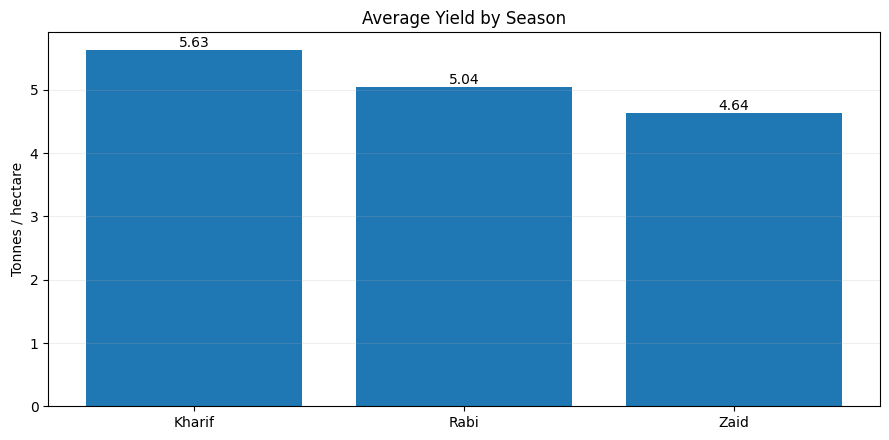

In [5]:
season_order = ["Kharif", "Rabi", "Zaid"]

fig, ax = plt.subplots(figsize=(9,4.5))
plot_vals = [season_summary.loc[s, "Avg_Yield_t_ha"] for s in season_order]
bars = ax.bar(season_order, plot_vals)
ax.set_title("Average Yield by Season")
ax.set_ylabel("Tonnes / hectare")
ax.grid(axis="y", alpha=0.2)
for b, v in zip(bars, plot_vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


### Seasonal takeaway

Kharif is the strongest season in this dataset on average and in total profit. Rabi remains viable but weaker. Zaid has the lowest average yield, lowest water efficiency and negative aggregate profit, so it should be treated as the highest-caution season rather than simply a smaller version of the other two.


## 4. Crop × season analysis

Season alone can hide the real driver. A crop may perform well in one season and poorly in another. The cross-tabulation below identifies where economic value is actually concentrated.


In [6]:
crop_season = (
    df_clean.groupby(["Season","Crop"])
    .agg(
        Farms=("Farm_ID","count"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha","mean"),
        Avg_Profit_INR=("Profit_INR","mean"),
        Total_Profit_INR=("Profit_INR","sum"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
        Avg_Risk_pct=("Disease_Pest_Risk_pct","mean"),
    )
    .reset_index()
    .sort_values("Total_Profit_INR", ascending=False)
)

display(crop_season.head(12).round(2))


,Season,Crop,Farms,Avg_Yield_t_ha,Avg_Profit_INR,Total_Profit_INR,Avg_Water_Efficiency,Avg_Risk_pct
0,Kharif,Chilli,185,1.730,"954,380.420",176560378,3.260,52.810
6,Kharif,Sugarcane,125,53.460,"1,000,790.810",125098851,36.000,54.020
8,Rabi,Chilli,163,1.470,"638,572.500",104087317,2.890,40.590
14,Rabi,Sugarcane,129,43.290,"731,612.860",94378059,27.920,39.850
1,Kharif,Cotton,215,1.370,"216,999.550",46654903,2.130,54.240
22,Zaid,Sugarcane,51,38.420,"583,635.800",29765426,23.390,38.350
16,Zaid,Chilli,64,1.200,"448,659.090",28714182,2.200,40.500
9,Rabi,Cotton,201,1.200,"107,343.590",21576061,1.940,41.540
2,Kharif,Groundnut,193,1.480,"108,265.440",20895230,3.580,54.280
4,Kharif,Pulses,221,1.040,"43,338.900",9577896,3.350,54.960


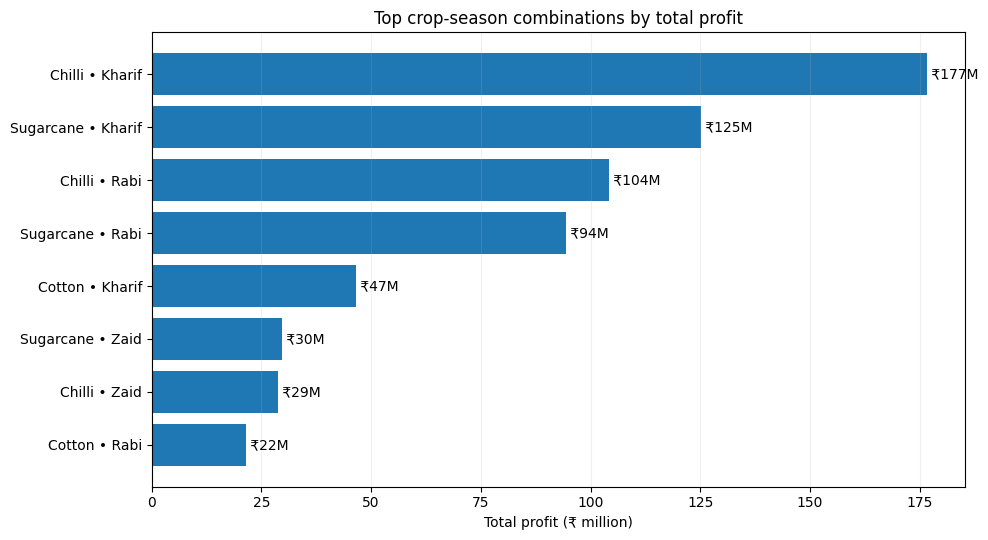

In [7]:
top8 = crop_season.head(8).copy()
top8["label"] = top8["Crop"] + " • " + top8["Season"]

fig, ax = plt.subplots(figsize=(10,5.5))
y = np.arange(len(top8))
v = top8["Total_Profit_INR"] / 1e6
ax.barh(y, v)
ax.set_yticks(y, top8["label"])
ax.invert_yaxis()
ax.set_xlabel("Total profit (₹ million)")
ax.set_title("Top crop-season combinations by total profit")
ax.grid(axis="x", alpha=0.2)
for yi, vi in zip(y, v):
    ax.text(vi, yi, f" ₹{vi:.0f}M", va="center")
plt.tight_layout()
plt.show()


In [8]:
kharif = crop_season[crop_season["Season"]=="Kharif"].sort_values("Total_Profit_INR", ascending=False)
kharif_top2_share = kharif.head(2)["Total_Profit_INR"].sum() / kharif["Total_Profit_INR"].sum() * 100

print(f"Top two Kharif crop combinations contribute {kharif_top2_share:.1f}% of Kharif total profit.")
display(kharif.head(5).round(2))


Top two Kharif crop combinations contribute 94.8% of Kharif total profit.


,Season,Crop,Farms,Avg_Yield_t_ha,Avg_Profit_INR,Total_Profit_INR,Avg_Water_Efficiency,Avg_Risk_pct
0,Kharif,Chilli,185,1.730,"954,380.420",176560378,3.260,52.810
6,Kharif,Sugarcane,125,53.460,"1,000,790.810",125098851,36.000,54.020
1,Kharif,Cotton,215,1.370,"216,999.550",46654903,2.130,54.240
2,Kharif,Groundnut,193,1.480,"108,265.440",20895230,3.580,54.280
4,Kharif,Pulses,221,1.040,"43,338.900",9577896,3.350,54.960


## 5. Irrigation and water productivity

Raw water use is not enough to judge performance. The more useful question is how much output is obtained per 1,000 cubic metres of water.


In [9]:
irrigation_summary = (
    df_clean.groupby("Irrigation_Method")
    .agg(
        Farms=("Farm_ID","count"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha","mean"),
        Avg_Profit_INR=("Profit_INR","mean"),
        Avg_Water_m3=("Water_Used_m3","mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
        Avg_Risk_pct=("Disease_Pest_Risk_pct","mean"),
    )
    .sort_values("Avg_Water_Efficiency", ascending=False)
)

display(irrigation_summary.round(2))


,Farms,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Water_m3,Avg_Water_Efficiency,Avg_Risk_pct
Irrigation_Method,,,,,,
Rainfed,1041,4.600,"79,050.370","3,549.550",7.560,46.490
Drip,915,6.580,"219,626.000","5,918.750",6.270,45.790
Sprinkler,734,5.160,"91,121.080","6,208.260",4.670,46.480
Flood,1310,4.860,"73,354.020","8,026.470",3.440,46.600


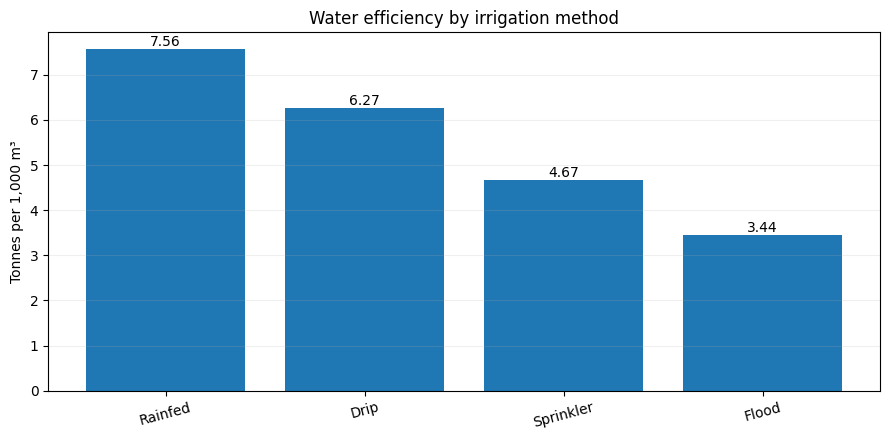

In [10]:
fig, ax = plt.subplots(figsize=(9,4.5))
vals = irrigation_summary["Avg_Water_Efficiency"]
bars = ax.bar(irrigation_summary.index, vals)
ax.set_title("Water efficiency by irrigation method")
ax.set_ylabel("Tonnes per 1,000 m³")
ax.grid(axis="y", alpha=0.2)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6. Relationship analysis

Correlation is used as a screening tool, not as proof of causation. Spearman correlation is appropriate here because the dataset contains strong skew and extreme values in variables such as yield and profit.


In [11]:
relationship_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
    "Soil_pH", "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct",
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR", "Profit_INR"
]

spearman_yield = (
    df_clean[relationship_cols]
    .corr(method="spearman")["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

display(spearman_yield.head(10).round(3))
print()
display(spearman_yield.tail(6).round(3))


Yield_Tonnes_Ha                 1.000
Water_Efficiency_t_per_1000m3   0.736
Profit_INR                      0.489
Revenue_INR                     0.410
Rainfall_mm                     0.130
Soil_Moisture_pct               0.097
Nitrogen_kg_ha                  0.082
Humidity_pct                    0.081
Disease_Pest_Risk_pct           0.065
Phosphorus_kg_ha                0.047
Name: Yield_Tonnes_Ha, dtype: float64

Avg_Temperature_C         0.002
Seed_Quality_Score       -0.000
Pesticide_Litre_ha       -0.000
Soil_pH                  -0.031
Sunlight_Hours_Day       -0.051
Market_Price_INR_Tonne   -0.579
Name: Yield_Tonnes_Ha, dtype: float64

In [12]:
for col in ["Water_Efficiency_t_per_1000m3", "Profit_INR", "Market_Price_INR_Tonne"]:
    rho, p = spearmanr(df_clean[col], df_clean["Yield_Tonnes_Ha"])
    print(f"Yield vs {col}: rho={rho:.3f}, p={p:.3e}")


Yield vs Water_Efficiency_t_per_1000m3: rho=0.736, p=0.000e+00
Yield vs Profit_INR: rho=0.489, p=1.180e-239
Yield vs Market_Price_INR_Tonne: rho=-0.579, p=0.000e+00


## 7. Statistical test: does season matter for profit?

Profit is highly skewed, so a Kruskal–Wallis test is used instead of assuming normality.

Null hypothesis: profit distributions are the same across the three seasons.


In [13]:
groups = [
    group["Profit_INR"].values
    for _, group in df_clean.groupby("Season")
]

kw_stat, kw_p = kruskal(*groups)
print(f"Kruskal-Wallis H={kw_stat:.3f}, p={kw_p:.3e}")

if kw_p < 0.05:
    print("Result: seasonal profit differences are statistically significant in this dataset.")
else:
    print("Result: the test does not provide strong evidence of a seasonal difference.")


Kruskal-Wallis H=101.926, p=7.363e-23
Result: seasonal profit differences are statistically significant in this dataset.


## 8. Outlier awareness

The dataset contains extreme observations. Those records are important because they may represent genuinely high-performing or distressed farms, but they can dominate simple averages.

For operational decisions, both mean and median should be viewed together.


In [14]:
outlier_view = season_summary[
    ["Avg_Yield_t_ha","Median_Yield_t_ha","Avg_Profit_INR","Median_Profit_INR"]
].copy()

display(outlier_view.round(2))

print("Highest yield records:")
display(
    df_clean.nlargest(5, "Yield_Tonnes_Ha")[
        ["Farm_ID","State","Crop","Season","Yield_Tonnes_Ha","Production_Tonnes","Profit_INR"]
    ]
)

print("Largest losses:")
display(
    df_clean.nsmallest(5, "Profit_INR")[
        ["Farm_ID","State","Crop","Season","Profit_INR","Total_Cost_INR","Revenue_INR"]
    ]
)


,Avg_Yield_t_ha,Median_Yield_t_ha,Avg_Profit_INR,Median_Profit_INR
Season,,,,
Kharif,5.630,1.940,"178,914.650","38,808.000"
Rabi,5.040,1.670,"87,689.470","-3,187.000"
Zaid,4.640,1.460,"-24,804.820","-62,144.000"


Highest yield records:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,SF11716,Gujarat,Sugarcane,Kharif,101.440,641.100,1608291
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,95.790,"1,424.400",3330582
3525,SF13526,Andhra Pradesh,Sugarcane,Rabi,93.130,648.180,1471529
1464,SF11465,Gujarat,Sugarcane,Kharif,91.980,703.650,2216708
3523,SF13524,Karnataka,Sugarcane,Kharif,91.460,75.000,234320


Largest losses:


,Farm_ID,State,Crop,Season,Profit_INR,Total_Cost_INR,Revenue_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,-1019223,1299362,280139
2210,SF12211,Andhra Pradesh,Wheat,Rabi,-995195,1097692,102497
3625,SF13626,Punjab,Maize,Rabi,-981050,1207553,226503
2182,SF12183,Andhra Pradesh,Rice,Kharif,-976860,1297725,320865
104,SF10105,Gujarat,Wheat,Zaid,-965197,1063989,98792


## 9. Seasonal Opportunity Score

To convert the analysis into a practical decision aid, each crop-season combination is scored using three transparent components:

- 50% profit level
- 30% water efficiency
- 20% lower disease/pest risk

Each component is converted to a percentile across crop-season combinations before weighting. This is a ranking tool, not a predictive model.


In [15]:
decision = crop_season.copy()

def percentile_score(s, higher_is_better=True):
    ranks = s.rank(pct=True)
    return ranks if higher_is_better else 1 - ranks

decision["Profit_Score"] = percentile_score(decision["Avg_Profit_INR"], True)
decision["Water_Score"] = percentile_score(decision["Avg_Water_Efficiency"], True)
decision["Risk_Score"] = percentile_score(decision["Avg_Risk_pct"], False)

decision["Seasonal_Opportunity_Score"] = (
    0.50 * decision["Profit_Score"] +
    0.30 * decision["Water_Score"] +
    0.20 * decision["Risk_Score"]
) * 100

decision_ranked = decision.sort_values(
    "Seasonal_Opportunity_Score", ascending=False
)

display(
    decision_ranked[
        ["Season","Crop","Farms","Avg_Profit_INR","Avg_Water_Efficiency",
         "Avg_Risk_pct","Seasonal_Opportunity_Score"]
    ].head(15).round(2)
)


,Season,Crop,Farms,Avg_Profit_INR,Avg_Water_Efficiency,Avg_Risk_pct,Seasonal_Opportunity_Score
14,Rabi,Sugarcane,129,"731,612.860",27.920,39.850,86.250
22,Zaid,Sugarcane,51,"583,635.800",23.390,38.350,85.830
6,Kharif,Sugarcane,125,"1,000,790.810",36.000,54.020,85.000
0,Kharif,Chilli,185,"954,380.420",3.260,52.810,70.000
8,Rabi,Chilli,163,"638,572.500",2.890,40.590,66.670
16,Zaid,Chilli,64,"448,659.090",2.200,40.500,59.580
2,Kharif,Groundnut,193,"108,265.440",3.580,54.280,56.670
10,Rabi,Groundnut,177,"10,416.540",2.900,39.760,56.670
11,Rabi,Maize,233,"-89,133.400",5.460,39.410,55.000
3,Kharif,Maize,234,"-39,332.670",6.050,54.820,52.920


## 10. Region-level consistency check

A seasonal pattern is more useful when it is not coming from one location only. The state × season table gives a quick consistency check.


In [16]:
state_season = (
    df_clean.groupby(["State","Season"])
    .agg(
        Farms=("Farm_ID","count"),
        Avg_Yield_t_ha=("Yield_Tonnes_Ha","mean"),
        Avg_Profit_INR=("Profit_INR","mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
    )
    .reset_index()
)

state_season_pivot = state_season.pivot_table(
    index="State", columns="Season", values="Avg_Profit_INR"
)

display(state_season_pivot.round(0))


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"169,316.000","26,316.000","-84,085.000"
Gujarat,"217,051.000","82,846.000","-106,930.000"
Karnataka,"201,226.000","70,953.000","23,311.000"
Madhya Pradesh,"134,242.000","61,576.000",210.000
Maharashtra,"168,801.000","159,582.000","-40,598.000"
Punjab,"133,779.000","169,295.000","62,110.000"
Tamil Nadu,"211,304.000","70,457.000","-15,175.000"
Telangana,"199,668.000","62,825.000","-34,621.000"


## 11. Final findings

**Finding 1 — Kharif is the strongest overall opportunity.**  
It has the highest average yield, the highest average profit, the highest total profit and the highest portfolio margin.

**Finding 2 — Zaid needs selective planning.**  
Its total profit is negative, its profitable-farm share is the lowest, and its water efficiency is the weakest of the three seasons.

**Finding 3 — Crop-season pairing matters.**  
The most valuable combinations are concentrated in a small group of high-return crop-season pairs, so season-wide averages alone are not enough for planning.

**Finding 4 — Water productivity is a major signal.**  
Water efficiency has a strong positive monotonic relationship with yield in the dataset, making it one of the clearest operational metrics.

**Finding 5 — Economics is broader than yield.**  
Profit also depends on market price, cost and crop mix. A high-yield record is not automatically a high-profit record.

**Finding 6 — Seasonal differences are statistically meaningful.**  
The Kruskal–Wallis test rejects the hypothesis of identical profit distributions across seasons.


## 12. Recommendations

1. Prioritize high-scoring crop-season combinations instead of treating every season uniformly.
2. Use Kharif as the benchmark season and investigate why its strongest crop combinations outperform the rest.
3. Treat Zaid as a selective-planning season: favor only combinations that clear profitability and water-efficiency thresholds.
4. Prefer water-efficient irrigation practices where operationally feasible, especially where the expected return remains strong.
5. Use median values alongside means when communicating farm performance because extreme observations are present.
6. Extend the project with yearly data, weather forecasts and market-price inputs before deploying it as a forecasting or recommendation system.


## 13. Exportable project outputs

The supporting script can save summary tables for a dashboard or report.


In [17]:
OUTPUT_DIR = "outputs"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

season_summary.reset_index().to_csv(
    f"{OUTPUT_DIR}/season_summary.csv", index=False
)

crop_season.to_csv(
    f"{OUTPUT_DIR}/crop_season_summary.csv", index=False
)

irrigation_summary.reset_index().to_csv(
    f"{OUTPUT_DIR}/irrigation_summary.csv", index=False
)

decision_ranked[
    ["Season","Crop","Farms","Avg_Profit_INR","Avg_Water_Efficiency",
     "Avg_Risk_pct","Seasonal_Opportunity_Score"]
].to_csv(
    f"{OUTPUT_DIR}/seasonal_opportunity_ranking.csv", index=False
)

df_clean.to_csv(
    f"{OUTPUT_DIR}/cleaned_seasonal_agriculture_dataset.csv", index=False
)

print("Saved project tables to:", OUTPUT_DIR)


Saved project tables to: outputs
